## Dataset for testing Tim's permutation response criterion.  - NEG responses
### 28 oct 2025

Set up for importing to Matlab. Will eventually add the function to the ResponseCriterion class in this repo.

Varied parameters:
- number of trials
- baseline firing rate, varied using a thresholded exponential function
- gain in firing rate for response period, given as a multiple of the baseline firing rate that's randomly pulled from an interval
- duration of response, randomly pulled from an interval 

Spike times are scaled such that spikes == 0 occurred right at the "stimulus" period. 




In [1]:
import sys
sys.path.append("/home/al/Documents/code/generate_responses")

from pathlib import Path

import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import savemat

from tqdm import tqdm

from config_plot import *
from generators import PoissonSpikeGenerator
from stats import ResponseCriteria

path_save = Path("/media/al/sansidk/simulated_responses/100k")

In [2]:
rng = np.random.default_rng()

# simulation params
n_samples = 50_000

min_trial_num = 5
scale_trial = 35

# response params
duration_range = [1., 1.5]

# baseline firing rate params
threshold = 1
scale = 3
rng = np.random.default_rng()

# beta params
beta_a_range = [1, 1.5]
beta_multiplier_range = [1.2, 2]


def determine_extra_trial_counts(n_trials, default=200, factor=5,):
    if n_trials < 50:
        n_supplement_trials = default
    else:
        n_supplement_trials = n_trials * factor
    return n_supplement_trials

def correct_empty_trials(trial_activity):
    return [[np.nan] if np.array(trial).size == 0 else trial for trial in trial_activity]

In [3]:
# generate non-responsive spike trains

# preallocate params
n_NC = int(n_samples / 2)

latency      = 0.350
duration     = 0.1
baseline_T   = 2
stimulus_T   = 2
dt           = 0.001
induce_refractory_period = True

u = rng.uniform(size=n_NC)
fr_baseline = threshold - scale * np.log(u)

n_trials_no_response = np.array(min_trial_num - scale_trial * np.log(u), dtype=int)
n_supplement_trials = np.vectorize(determine_extra_trial_counts)(n_trials_no_response)

NC_rasters = [None] * n_NC
NC_supplement_trials = [None] * n_NC

df_nc = pd.DataFrame({
    "response": np.zeros(n_NC, dtype=np.int8),
    "fr_baseline": fr_baseline.astype(float),
    "fr_response": fr_baseline.astype(float),
    "latency": np.full(n_NC, latency, dtype=float),
    "duration": np.full(n_NC, duration, dtype=float),
    "time_baseline": np.full(n_NC, baseline_T, dtype=float),
    "time_stimulus": np.full(n_NC, stimulus_T, dtype=float),
    "refractory_period_induced": np.ones(n_NC, dtype=np.int8),
})

for i, fr in enumerate(tqdm(fr_baseline)):
    n_trials = n_trials_no_response[i]
    n_supplement_trials = determine_extra_trial_counts(n_trials)

    baseline_fr  = fr
    response_fr  = fr

    generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period
)

    # generate trials
    trial_activity = generator.generate(n_trials)
    supp_trial_activity = generator.generate(n_supplement_trials)

    # rescale
    trial_activity = [t - baseline_T for t in trial_activity]    
    supp_trial_activity = [t - baseline_T for t in supp_trial_activity]

    NC_rasters[i] = correct_empty_trials(trial_activity)
    NC_supplement_trials[i] = correct_empty_trials(supp_trial_activity)

df_nc["rasters"] = NC_rasters
df_nc["supp_rasters"] = NC_supplement_trials


100%|██████████| 25000/25000 [04:03<00:00, 102.64it/s]


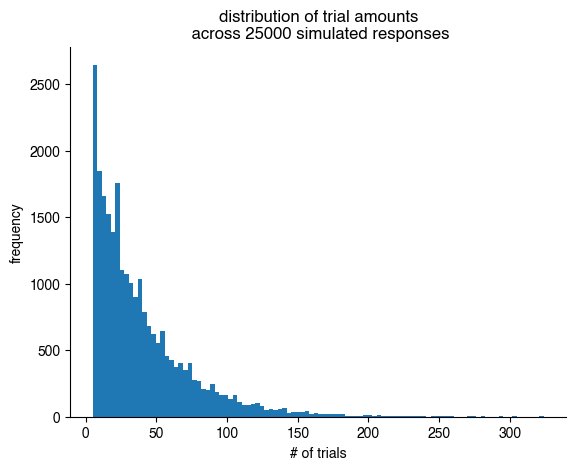

  0%|          | 0/25000 [00:00<?, ?it/s]

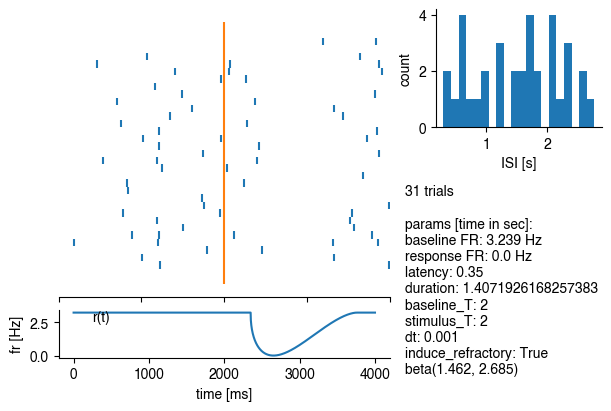

  0%|          | 1/25000 [00:00<3:06:47,  2.23it/s]

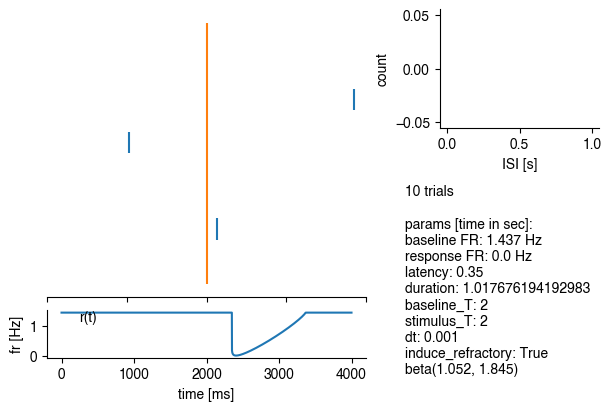

  0%|          | 2/25000 [00:01<4:04:54,  1.70it/s]

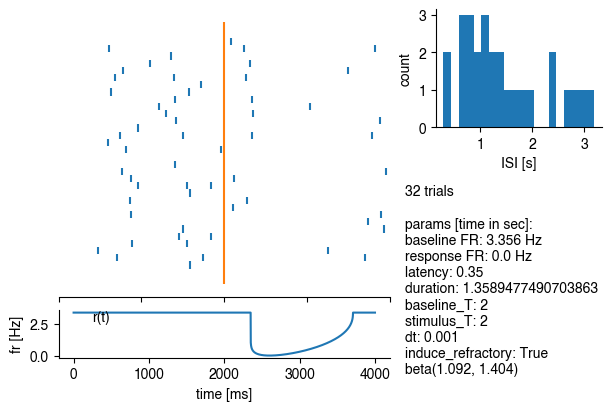

  0%|          | 3/25000 [00:01<3:40:14,  1.89it/s]

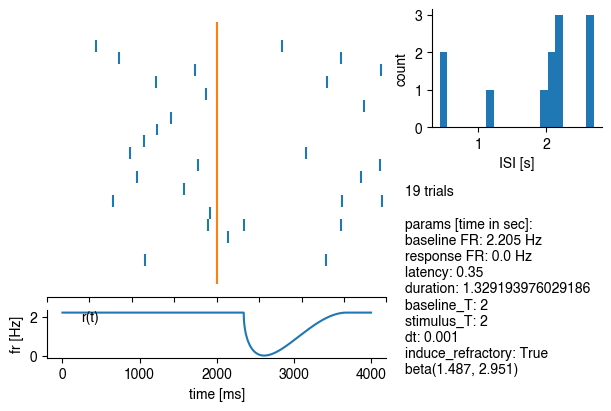

  0%|          | 4/25000 [00:02<3:30:02,  1.98it/s]

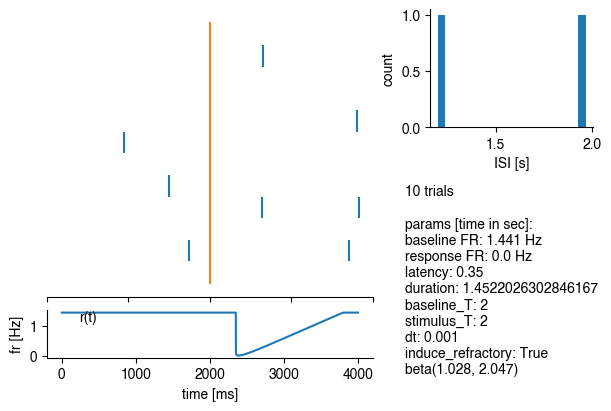

  0%|          | 5/25000 [00:02<3:21:14,  2.07it/s]

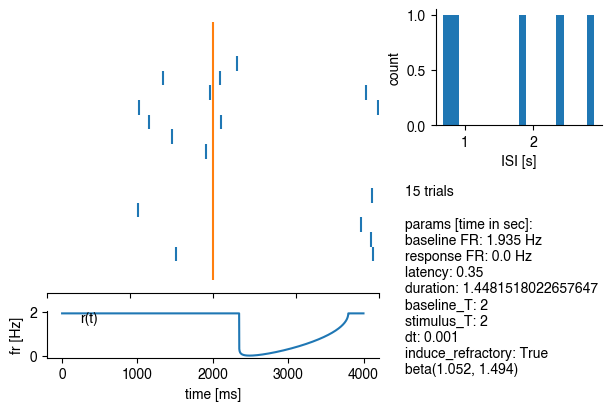

  0%|          | 6/25000 [00:02<3:18:08,  2.10it/s]

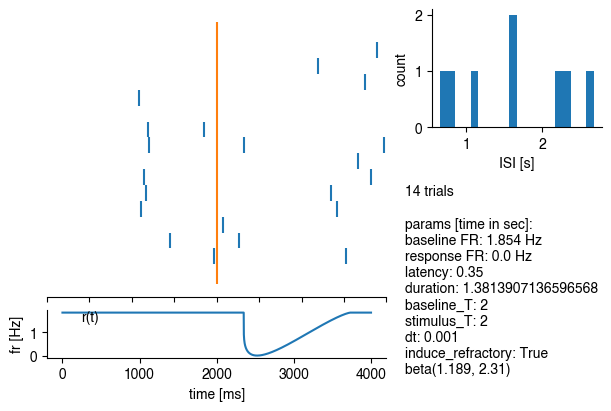

  0%|          | 7/25000 [00:03<3:16:52,  2.12it/s]

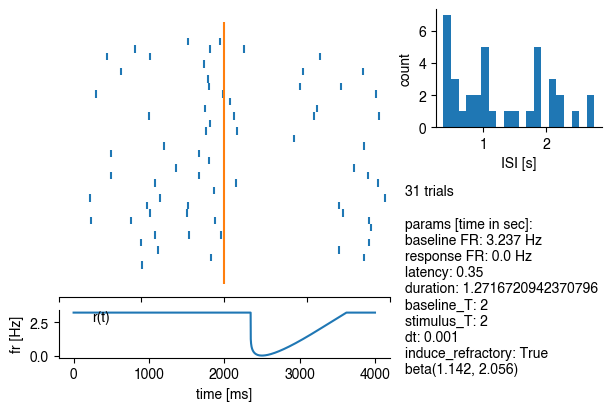

  0%|          | 8/25000 [00:03<3:15:45,  2.13it/s]

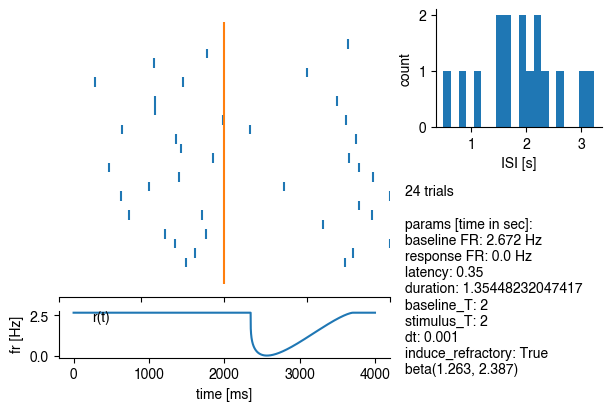

  0%|          | 9/25000 [00:04<3:18:07,  2.10it/s]

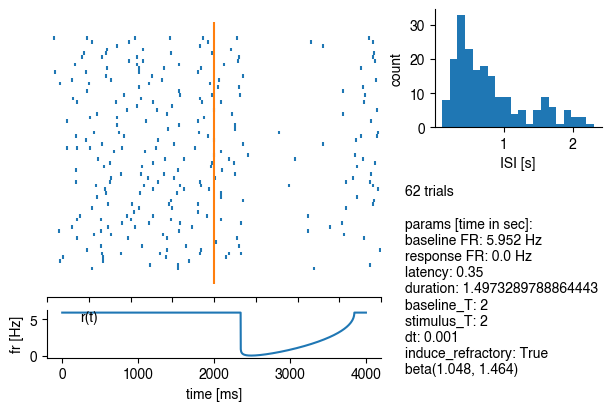

  0%|          | 10/25000 [00:04<3:21:29,  2.07it/s]

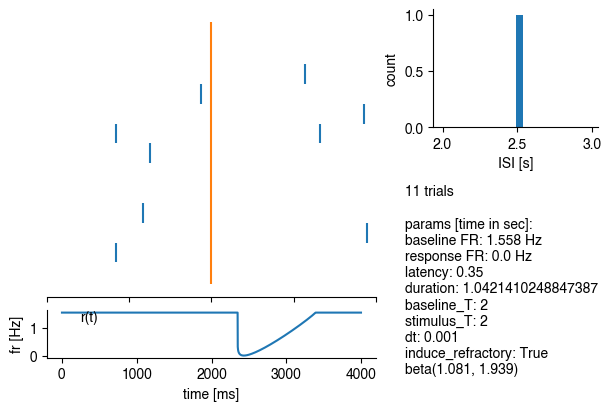

  0%|          | 11/25000 [00:05<3:18:37,  2.10it/s]

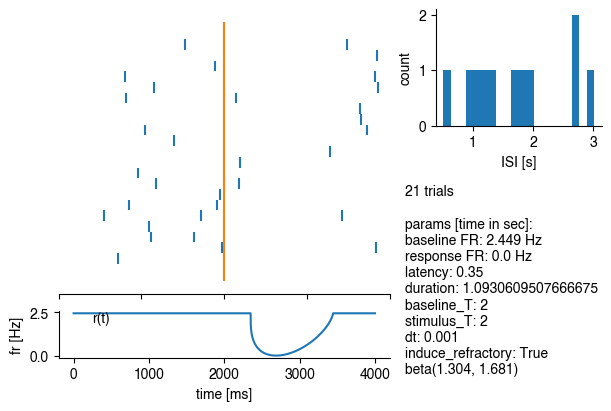

  0%|          | 12/25000 [00:05<3:17:59,  2.10it/s]

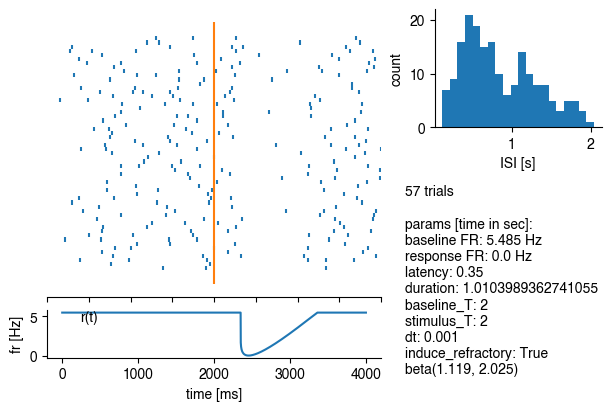

  0%|          | 13/25000 [00:06<3:19:35,  2.09it/s]

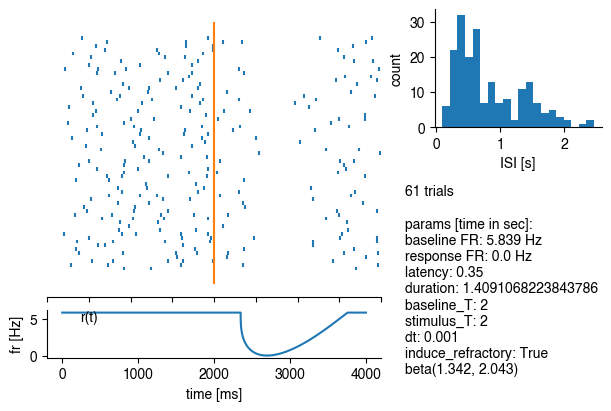

  0%|          | 14/25000 [00:06<3:19:12,  2.09it/s]

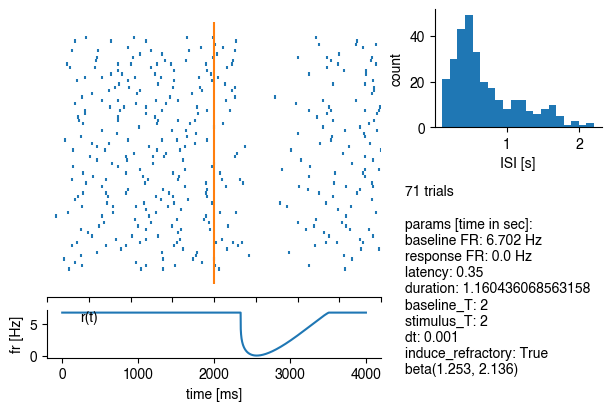

  0%|          | 15/25000 [00:07<3:20:37,  2.08it/s]

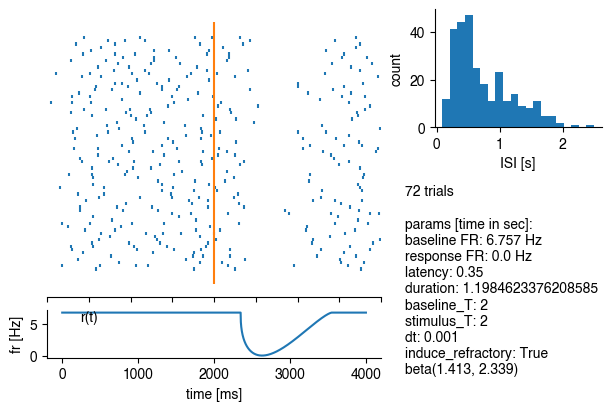

  0%|          | 16/25000 [00:07<3:21:32,  2.07it/s]

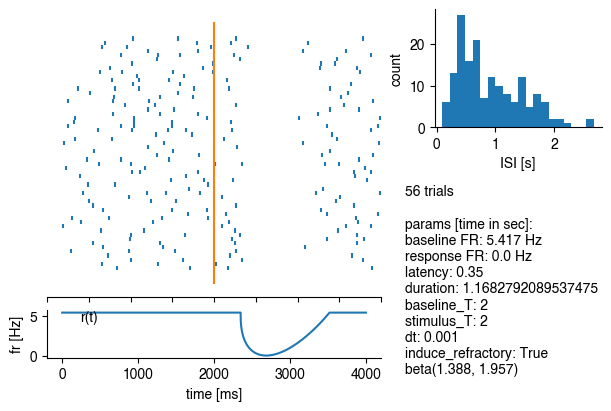

  0%|          | 17/25000 [00:08<3:22:21,  2.06it/s]

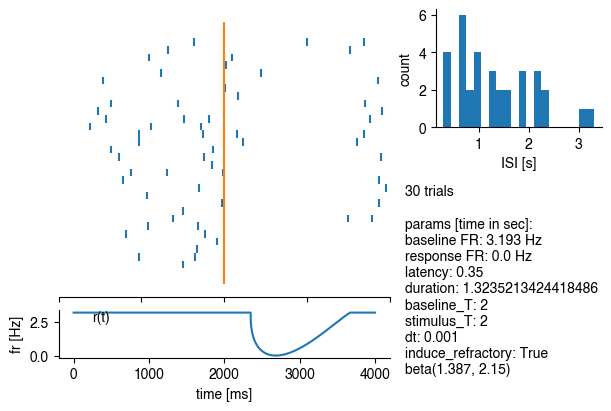

  0%|          | 18/25000 [00:08<3:17:38,  2.11it/s]

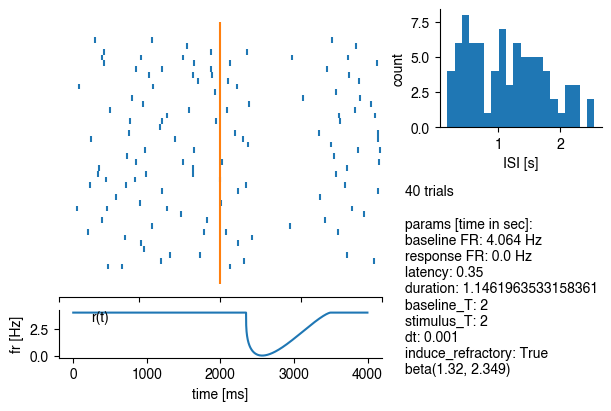

  0%|          | 19/25000 [00:09<4:01:03,  1.73it/s]

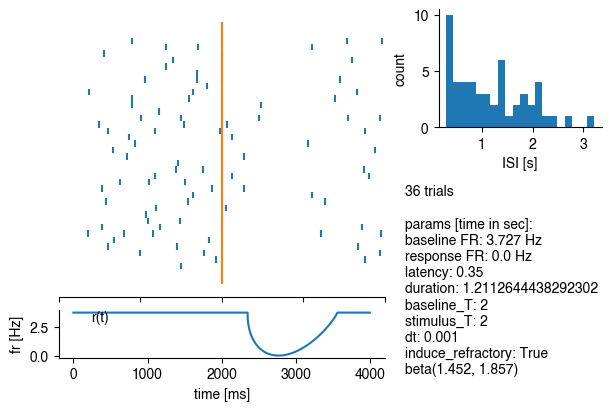

100%|██████████| 25000/25000 [04:22<00:00, 95.41it/s] 


In [4]:
# generate responsive spike trains

# preallocate params
n_C = int(n_samples / 2)

latency      = 0.350
baseline_T   = 2
stimulus_T   = 2
dt           = 0.001
induce_refractory_period = True



u = rng.uniform(size=n_C)

n_trials_responses = np.array(min_trial_num - scale_trial * np.log(u), dtype=int)
n_supplement_trials = np.vectorize(determine_extra_trial_counts)(n_trials_responses)

plt.hist(n_trials_responses, bins=100)
plt.title(f"distribution of trial amounts\n across {n_C} simulated responses")
plt.xlabel("# of trials")
plt.ylabel("frequency")
sns.despine()
plt.savefig(path_save / f"{datetime.today().strftime('%Y-%m-%d')}_distribution_trials.png")
plt.show()

fr_baseline = threshold - scale * np.log(u)
fr_response = np.zeros(n_C)

beta_a_s = np.random.uniform(beta_a_range[0], beta_a_range[1], size=n_C)
beta_multiplier_s = np.random.uniform(beta_multiplier_range[0], beta_multiplier_range[1], size=n_C)
beta_b_s = beta_a_s * beta_multiplier_s

durations = rng.uniform(duration_range[0], duration_range[1], size=n_C)

C_rasters = [None] * n_C
C_supplement_trials = [None] * n_C

df_c = pd.DataFrame({
    "response": np.ones(n_C, dtype=np.int8),
    "fr_baseline": fr_baseline.astype(float),
    "fr_response": fr_response.astype(float),
    "latency": np.full(n_C, latency, dtype=float),
    "duration": durations.astype(float),
    "time_baseline": np.full(n_C, baseline_T, dtype=float),
    "time_stimulus": np.full(n_C, stimulus_T, dtype=float),
    "refractory_period_induced": np.ones(n_C, dtype=np.int8),
    "beta_a": beta_a_s.astype(float),
    "beta_b_s": beta_b_s.astype(float),
})

for i, fr in enumerate(tqdm(fr_baseline)):
    n_trials = n_trials_responses[i]
    n_supplement_trials = determine_extra_trial_counts(n_trials)

    baseline_fr  = fr
    response_fr  = fr_response[i]
    
    duration = durations[i]

    a = beta_a_s[i]
    b = beta_b_s[i]

    generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    a=a,
    b=b,
)

    # generate trials
    trial_activity = generator.generate(n_trials)
    supp_trial_activity = generator.generate(n_supplement_trials)

    # rescale
    trial_activity = [t - baseline_T for t in trial_activity]    
    supp_trial_activity = [t - baseline_T for t in supp_trial_activity]

    C_rasters[i] = correct_empty_trials(trial_activity)
    C_supplement_trials[i] = correct_empty_trials(supp_trial_activity)

    if i < 20:

        fig, axes = plt.subplot_mosaic(
        [
            ["raster", "isi"],
            ["raster", "text"],
            ["r_t", "text"]
        ], 
        empty_sentinel="empty", 
        width_ratios=[2, 1],
        height_ratios=[1,1,0.4],
        figsize=(6,4),
        layout='constrained',

    )

        ax = axes["raster"]
        ax.eventplot(trial_activity)
        ymin, ymax = ax.get_ylim()
        ax.vlines(0, ymin, ymax, colors="tab:orange")
        ax.set_xlim(-1*baseline_T, stimulus_T)
        ax.set_xticklabels([])
        ax.set_yticks([])
        sns.despine(left=True, ax=ax)

        ax = axes["isi"]
        isis = np.concatenate([np.diff(t) for t in trial_activity])
        ax.hist(isis, bins=20)
        sns.despine(ax=ax)
        ax.set_xlabel("ISI [s]")
        ax.set_ylabel("count")

        ax = axes["r_t"]
        ax.plot(generator.r_t)
        ax.text(
            0.1, 1, "r(t)",
            transform=ax.transAxes,   # use axes coords, not data coords
            ha="left", va="top"      # align text to the top-right
        )
        ax.set_xlabel("time [ms]")
        ax.set_ylabel("fr [Hz]")
        sns.despine(ax=ax)

        ax = axes["text"]

        ax.set_in_layout(False) 
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_anchor('NW')

        s = (
            f"{n_trials} trials\n\n"
            f"params [time in sec]:\n"
            f"baseline FR: {round(baseline_fr, 3)} Hz\n"
            f"response FR: {round(response_fr, 3)} Hz\n"
            f"latency: {latency}\n"
            f"duration: {duration}\n"
            f"baseline_T: {baseline_T}\n"
            f"stimulus_T: {stimulus_T}\n"
            f"dt: {dt}\n"
            f"induce_refractory: {induce_refractory_period}\n"
            f"beta({round(a, 3)}, {round(b, 3)})"

        )

        ax.text(
            0.0, 1.0,
            s,
            transform=ax.transAxes,
            ha="left",
            va="top",
            wrap=True
        )

        ax.set_xticks([])
        ax.set_yticks([])

        sns.despine(left=True, bottom=True, ax=ax)
        
        left_ax = axes["raster"]
        bbox = left_ax.get_position()

        fname = f"{i}_{n_trials}trials_{int(baseline_fr)}bFR_{int(response_fr)}rFR_{round(duration,2)}duration_beta{round(a,2)}-{round(b,2)}.png"
        fig.savefig(path_save / "example_responses" / fname)
        plt.show()

df_c["rasters"] = C_rasters
df_c["supp_rasters"] = C_supplement_trials


In [5]:
dataset = pd.concat((df_nc, df_c))
dataset_randomized = dataset.sample(frac=1, random_state=rng.integers(1e9)).reset_index(drop=True)

In [6]:
mat_dict = {col: dataset_randomized[col].to_numpy() for col in dataset_randomized.columns}

# Save
savemat(path_save / f"{datetime.today().strftime('%Y-%m-%d')}_{int(n_samples)}_simulated_NEGATIVEresponses.mat", {"data": mat_dict})